# exp08 : the dynamics ladder, audited

exp08 concluded that the eb/rotation benefit comes from unsatisfiable prediction pressure rather than a
smoothness prior, and that the learned GRU is what makes the benefit transfer. This notebook recomputes
every number `experiments/exp08_ladder_README.md` publishes, then measures the six weaknesses the
writeup could not defend on its own.

Precompute: `experiments/analyze_exp08_diagnostics.py` (shipped epochs, cache fingerprints, an
independent probe re-fit). Everything else is computed inline so the arithmetic behind each verdict is
readable in the cell that prints it.

## Setup

Every artifact is read once here. `mean_resid` is renamed **`mean_perp_amp`** throughout: it is not a
pooling operator but `mean` with the amplitude basis (`p2p_scatter_ratio`, `depth_5_95`, `mad`, `iqr`)
linearly projected out, so it answers "what does mu carry beyond amplitude" and reads systematically
lower than `mean`.

In [1]:
import hashlib
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

root = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
exp = root / "experiments"
pd.set_option("display.width", 250)

pooling_label = {"mean": "mean", "mean_resid": "mean_perp_amp", "mean_std": "mean_std"}

probe = pd.concat([pd.read_csv(exp / "exp08_diag_probe_summary.csv"),
                   pd.read_csv(exp / "exp08_diag_lo_probe_summary.csv"),
                   pd.read_csv(exp / "exp07_diag_probe_summary.csv")], ignore_index=True)
shared_rows = probe[probe["cell"] == "untrained_w256"].groupby(["seed", "pooling", "task"])["pr_auc"].nunique()
assert shared_rows.max() == 1, "the three summary files disagree on the shared untrained arm"
probe = probe.drop_duplicates(["cell", "seed", "pooling", "task"])
ladder_gap = pd.read_csv(exp / "exp08_ladder_gap.csv")
menu = pd.read_csv(exp / "exp08_ladder_menu.csv")
scorecard = pd.read_csv(exp / "exp08_prechecks" / "new_task_scorecard.csv")
selection = pd.read_csv(exp / "exp08_diag_selection.csv")
fingerprint = pd.read_csv(exp / "exp08_diag_cache_fingerprint.csv")
refit = pd.read_csv(exp / "exp08_diag_refit.csv")
sig_resid = pd.read_csv(exp / "exp08_signature_dynunits_residual.csv")
sig_scaling = pd.read_csv(exp / "exp08_signature_dynunits_scaling.csv")
sig_cca = pd.read_csv(exp / "exp08_signature_dynunits_cca.csv")
sig_channel = pd.read_csv(exp / "exp08_signature_channel_probe.csv")

seeds = [0, 1, 2, 3, 4, 5]
fair_rungs = ["exp07_hann0p3_off", "exp08_smooth_lo", "exp08_linear", "exp08_frozen_lo", "exp08_frozen"]
saturated = ["exp08_smooth", "exp08_smooth_half"]
gru = "exp07_hann0p3_fbwd"
print("artifacts loaded")

artifacts loaded


The reproduction ledger is the audit's spine. Every published number goes through `check`, which records
PASS inside the display tolerance, DRIFT when the digits move but the claim does not, and FAIL when a
sign, a gate outcome or 0.01 is crossed. The notebook runs to completion either way and raises only in
the final cell, so one bad digit cannot cost the other measurements.

In [2]:
ledger = []


def check(item, quantity, got, want, tol=0.001, fail_tol=0.01):
    """
    Compare one recomputed quantity against the number the README publishes and record the outcome.
    Anything beyond `fail_tol`, and any sign flip, is a FAIL that stops the notebook in its last cell.
    """
    diff = abs(got - want)
    if want == 0 or got == 0:
        sign_flip = False # a published zero has no sign to flip; magnitude alone decides
    else:
        sign_flip = np.sign(got) != np.sign(want)
    if diff > fail_tol or sign_flip:
        status = "FAIL"
    elif diff > tol:
        status = "DRIFT"
    else:
        status = "PASS"
    ledger.append({"item": item, "quantity": quantity, "recomputed": got, "published": want,
                   "abs_diff": diff, "status": status})
    return status


def paired_delta(scores, cell_a, cell_b, task, pooling):
    """
    Seed-paired cell_a minus cell_b with both arms' seed spread entering through the difference (F17).
    This is the estimator analyze_exp08_ladder.py decided the gates on; the menu is rescored with it here.
    """
    a = scores[(scores["cell"] == cell_a) & (scores["task"] == task) & (scores["pooling"] == pooling)]
    b = scores[(scores["cell"] == cell_b) & (scores["task"] == task) & (scores["pooling"] == pooling)]
    joined = a.merge(b, on="seed", suffixes=("_a", "_b"))
    d = joined["score_a"] - joined["score_b"]
    return {"cell_a": cell_a, "cell_b": cell_b, "task": task, "pooling": pooling, "n_seeds": len(d),
            "mean_a": joined["score_a"].mean(), "mean_b": joined["score_b"].mean(),
            "delta": d.mean(), "se": d.std(ddof=1) / np.sqrt(len(d))}


print("ledger and estimator ready")

ledger and estimator ready


## A. Run integrity

Before any ladder number is trusted, the 36 exp08 runs plus the two reused exp07 reference arms have to
be the runs the tables claim: shipped past beta warmup, described by their own curve, and cached under
their own weights.

### A1. Which epoch actually shipped

Every exp08 probe, mu cache and menu score was built from `best_recon_aux.pt`, so that checkpoint's
epoch is the one that has to be sane. `best.pt` is carried alongside because the two disagree by up to
75 epochs and no downstream table uses it.

In [3]:
shipped = selection[selection["ckpt"] == "best_recon_aux"].copy()
integrity = pd.DataFrame({
    "runs": [len(shipped)],
    "epoch_below_warmup": [(shipped["epoch"] < shipped["beta_warmup_epochs"]).sum()],
    "epoch_missing_from_curve": [(~shipped["curve_has_epoch"]).sum()],
    "epoch_after_last": [(shipped["epoch"] > shipped["last_epoch"]).sum()],
    "curve_not_starting_at_zero": [(shipped["first_epoch"] != 0).sum()],
    "select_monitor_mismatch": [(shipped["best_select"] - shipped["val_monitor_recon_aux"]).abs().gt(1e-6).sum()],
})
display(integrity)
display(shipped[shipped["first_epoch"] != 0][["cell", "seed", "first_epoch", "last_epoch", "n_curve_rows", "epoch"]])
display(selection.pivot_table(index=["cell", "seed"], columns="ckpt", values="epoch").head(12))

,runs,epoch_below_warmup,epoch_missing_from_curve,epoch_after_last,curve_not_starting_at_zero,select_monitor_mismatch
0,48,0,0,0,1,0


,cell,seed,first_epoch,last_epoch,n_curve_rows,epoch
90,exp07_hann0p3_fbwd,3,37,99,63,96


ckpt                     best  best_recon_aux
cell               seed                      
exp07_hann0p3_fbwd 0     93.0            99.0
                   1     77.0            95.0
                   2     96.0            97.0
                   3     95.0            96.0
                   4     10.0            52.0
                   5     88.0            95.0
exp07_hann0p3_off  0     49.0            49.0
                   1     40.0            40.0
                   2     97.0            96.0
                   3     98.0            97.0
                   4     36.0            36.0
                   5     96.0            93.0

#### Plain-English read of A1

All 38 shipped checkpoints sit past beta warmup, appear in their own curve, and carry a `best_select`
value equal to the curve's `val/monitor_recon_aux` at that epoch, so the probe tables and the curves
describe the same runs. One reused reference run, `exp07_hann0p3_fbwd` seed 3, has a curve dump that
starts at epoch 37 because the run was resumed and W&B kept only the continuation: its epoch-range
statistics are unusable, its shipped epoch is not. `best` and `best_recon_aux` disagree by up to 75
epochs, which is a caveat about a checkpoint nothing here reads, not a defect.

### A2. Latent width at the shipped epoch

The ladder's mechanism story is a story about how many latent units survive. If the arms' widths at the
shipped epoch do not match the widths the writeup quotes, the phase argument is describing other runs.

In [4]:
width = shipped[shipped["cell"].str.startswith("exp08")]
display(width.pivot_table(index="seed", columns="cell", values="val_n_active_units"))
observed = width.groupby("cell")["val_n_active_units"].agg(["min", "max"])
display(observed)

check("#6 selection", "smooth active units (all seeds)", observed.loc["exp08_smooth", "max"], 1.0, tol=0.0, fail_tol=0.5)
check("#6 selection", "smooth_half active units (all seeds)", observed.loc["exp08_smooth_half", "max"], 1.0, tol=0.0, fail_tol=0.5)
check("#6 selection", "smooth_lo active units", observed.loc["exp08_smooth_lo", "max"], 4.0, tol=0.0, fail_tol=1.5)
check("#6 selection", "frozen_lo active units (max)", observed.loc["exp08_frozen_lo", "max"], 5.0, tol=0.0, fail_tol=1.5)
check("#6 selection", "frozen wide active units (min)", observed.loc["exp08_frozen", "min"], 69.0, tol=0.0, fail_tol=5.0)
check("#6 selection", "frozen wide active units (max)", observed.loc["exp08_frozen", "max"], 114.0, tol=0.0, fail_tol=5.0)
check("#2 linear", "linear active units (max)", observed.loc["exp08_linear", "max"], 29.0, tol=0.0, fail_tol=5.0)
display(pd.DataFrame(ledger).tail(7))

cell,exp08_frozen,exp08_frozen_lo,exp08_linear,exp08_smooth,exp08_smooth_half,exp08_smooth_lo
seed,,,,,,
0,69.0,5.0,4.0,1.0,1.0,4.0
1,97.0,5.0,15.0,1.0,1.0,4.0
2,116.0,5.0,8.0,1.0,1.0,3.0
3,109.0,5.0,6.0,1.0,1.0,4.0
4,102.0,5.0,28.0,1.0,1.0,4.0
5,101.0,4.0,8.0,1.0,1.0,4.0


,min,max
cell,,
exp08_frozen,69.0,116.0
exp08_frozen_lo,4.0,5.0
exp08_linear,4.0,28.0
exp08_smooth,1.0,1.0
exp08_smooth_half,1.0,1.0
exp08_smooth_lo,3.0,4.0


,item,quantity,recomputed,published,abs_diff,status
0,#6 selection,smooth active units (all seeds),1.0,1.0,0.0,PASS
1,#6 selection,smooth_half active units (all seeds),1.0,1.0,0.0,PASS
2,#6 selection,smooth_lo active units,4.0,4.0,0.0,PASS
3,#6 selection,frozen_lo active units (max),5.0,5.0,0.0,PASS
4,#6 selection,frozen wide active units (min),69.0,69.0,0.0,PASS
5,#6 selection,frozen wide active units (max),116.0,114.0,2.0,DRIFT
6,#2 linear,linear active units (max),28.0,29.0,1.0,DRIFT


#### Plain-English read of A2

The collapse claims hold exactly: both saturated smooth arms sit at one active unit in all six seeds,
`smooth_lo` at three to four, `frozen_lo` at four to five. The wide arms are a digit off the writeup,
`frozen` spanning 69 to 116 rather than 69 to 114 and `linear` 4 to 28 rather than 4 to 29, which
changes no claim but means attack item 2's "18/29-unit seeds" should read 15/28. These two rows are
checked against the numbers the writeup carried when the audit ran, so they stay DRIFT here; the
README was corrected to the audited values afterwards.

### A3. Stop-epoch heterogeneity

Runs early-stopped between epochs 38 and 99 under a cosine schedule annealed over `max_epochs`, so they
shipped at different learning-rate exposure. If stop epoch predicts probe score within a cell, pairing
arms across the ladder compares training lengths as much as objectives.

In [5]:
v1_scores = probe.rename(columns={"pr_auc": "score"})
stop = shipped[["cell", "seed", "epoch", "last_epoch", "lr", "val_n_active_units"]]
merged = stop.merge(v1_scores[v1_scores["pooling"] == "mean"], on=["cell", "seed"])

rows = []
for (cell, task), group in merged.groupby(["cell", "task"]):
    if group["last_epoch"].nunique() < 3:
        continue
    rho, pval = stats.spearmanr(group["last_epoch"], group["score"])
    rows.append({"cell": cell, "task": task, "n": len(group), "rho_stop_vs_score": rho, "p": pval,
                 "stop_min": group["last_epoch"].min(), "stop_max": group["last_epoch"].max()})
stop_corr = pd.DataFrame(rows)
display(stop_corr.pivot_table(index="cell", columns="task", values="rho_stop_vs_score").round(3))
display(stop_corr.groupby("task")["rho_stop_vs_score"].describe()[["count", "mean", "min", "max"]].round(3))
print("cells with any |rho| > 0.8:", stop_corr[stop_corr["rho_stop_vs_score"].abs() > 0.8]["cell"].nunique())

task,eb,pulsating,rotation,transit
cell,,,,
exp07_hann0p3_off,-0.152,0.516,-0.516,-0.759
exp08_frozen,0.928,0.667,0.000,-0.116
exp08_smooth,-0.522,-0.812,0.609,-0.725
exp08_smooth_half,-0.812,-0.174,0.232,-0.841
exp08_smooth_lo,0.034,0.169,0.778,-0.068


,count,mean,min,max
task,,,,
eb,5.0,-0.105,-0.812,0.928
pulsating,5.0,0.073,-0.812,0.667
rotation,5.0,0.220,-0.516,0.778
transit,5.0,-0.502,-0.841,-0.068


cells with any |rho| > 0.8: 3


#### Plain-English read of A3

Stop epoch does not order the probe scores in any consistent direction. Four of the twenty cell-task
correlations exceed 0.8 in magnitude, but they disagree in sign (frozen on eb at +0.93 against
smooth_half on eb at minus 0.81), and no task shows a coherent trend across cells. On six points per
cell that pattern is what noise looks like, so cross-arm seed pairing is not comparing learning-rate
exposure in disguise. The cells that early-stopped hardest are the collapsed smooth arms, whose probe
level is set by the collapse rather than by how long they ran.

### A4. Cache provenance

`new_task_scorecard` takes one `--ckpt-dir` for the whole fan, so any arm whose subset cache was missing
would have been silently rebuilt from `exp08_linear`'s weights. The caches store no provenance, so
identity is reconstructed from content: a fallback makes two arms share bytes.

In [6]:
collisions = fingerprint[fingerprint.duplicated("sha1", keep=False)]
summary = fingerprint.groupby("kind").agg(caches=("name", "size"), unique_hashes=("sha1", "nunique"),
                                          stars=("n_stars", "min"), z_dim=("z_dim", "max"))
display(summary)
print("caches sharing a content hash:", len(collisions))

subset = fingerprint[fingerprint["kind"] == "subset"].copy()
subset["cell"] = "exp08_" + subset["name"].str.rsplit("_s", n=1).str[0]
display(subset.groupby("cell")[["dims_active", "spread_median", "total_var"]].agg(["min", "max"]).round(3))

tie = subset.merge(shipped[["cell", "seed", "val_n_active_units"]].assign(
    name=shipped["cell"].str.replace("exp08_", "", regex=False) + "_s" + shipped["seed"].astype(str)),
    on="name", how="inner")
rho, pval = stats.spearmanr(tie["dims_active"], tie["val_n_active_units"])
print("spearman(cache latent width, training active units):", round(rho, 3), "p", pval)

,caches,unique_hashes,stars,z_dim
kind,,,,
pool,36,36,55596,128
shared,60,60,2021,128
subset,36,36,32736,128


caches sharing a content hash: 0


dims_active      spread_median        total_var       
                          min  max           min    max       min    max
cell                                                                    
exp08_frozen              123  128         0.128  0.223     4.863  7.924
exp08_frozen_lo            27   64         0.036  0.050     2.062  2.172
exp08_linear               92  118         0.060  0.084     2.330  2.821
exp08_smooth                1    1         0.001  0.005     0.640  0.708
exp08_smooth_half           1    1         0.001  0.011     0.693  0.831
exp08_smooth_lo             4    8         0.004  0.012     1.075  1.157

spearman(cache latent width, training active units): 0.973 p 3.5760281605558794e-23


#### Plain-English read of A4

No two of the 132 caches share a content hash, so no arm was built from another arm's checkpoint: the
documented fallback trap did not fire. The widths also tie each cache back to the right arm, ordering
the cells exactly as their training curves do (rank correlation near one) with the collapsed smooth arms
showing a single spread-carrying dimension. The cache count is a KL-free spread criterion, so it is
larger than the training-time active-unit count on the wide arms; only the ordering and the collapsed
arms are meant to agree.

### A5. Duplicated off-arm rows in the signature suite

The signature run recomputed the `off` arm once per pair, so `exp08_signature_dynunits_scaling.csv`
carries four copies of every off row. Aggregating without dedup would weight the reference arm four
times.

In [7]:
off_rows = sig_scaling[sig_scaling["arm"] == "off"]
copies = off_rows.groupby(["cell", "seed", "readout", "task"])["pr_auc"].agg(["size", "nunique", "min", "max"])
print("off-arm keys:", len(copies), "| copies per key:", sorted(copies["size"].unique()))
print("keys whose copies disagree:", (copies["nunique"] > 1).sum(), "| max spread within key:", (copies["max"] - copies["min"]).max())

sig_scaling_dedup = sig_scaling.drop_duplicates(["cell", "seed", "readout", "task", "arm"])
naive = sig_scaling.groupby(["arm", "readout"])["pr_auc"].mean()
clean = sig_scaling_dedup.groupby(["arm", "readout"])["pr_auc"].mean()
display(pd.DataFrame({"naive": naive, "deduped": clean, "shift": clean - naive}).round(4))

off-arm keys: 72 | copies per key: [np.int64(4)]
keys whose copies disagree: 0 | max spread within key: 0.0


naive  deduped  shift
arm  readout                            
fbwd mu_active    0.5578   0.5578    0.0
     mu_unscaled  0.5000   0.5000    0.0
     mu_whitened  0.5577   0.5577    0.0
off  mu_active    0.5551   0.5551    0.0
     mu_unscaled  0.4587   0.4587    0.0
     mu_whitened  0.5551   0.5551    0.0

#### Plain-English read of A5

The four copies of every off-arm row are numerically identical, so the duplication was bookkeeping, not
two different scorings of the same arm. Deduplicating shifts no readout mean, which means every
published signature number computed from this file is unaffected; the dedup stays in the pipeline
because a future aggregation grouped differently would not be so lucky.

## B. The ladder, recomputed

The ladder table is the writeup's centrepiece. Here it is rebuilt from the per-seed probe scores under
both readouts: `mean` for absolute capability and `mean_perp_amp` for what survives removing amplitude.

In [8]:
cells_order = ["exp07_hann0p3_off", "exp08_smooth_lo", "exp08_linear", "exp08_frozen_lo",
               "exp08_frozen", "exp07_hann0p3_fbwd"]
published_ladder = {
    ("eb", "exp07_hann0p3_off"): 0.510, ("eb", "exp08_smooth_lo"): 0.529, ("eb", "exp08_linear"): 0.575,
    ("eb", "exp08_frozen_lo"): 0.536, ("eb", "exp08_frozen"): 0.577, ("eb", "exp07_hann0p3_fbwd"): 0.590,
    ("rotation", "exp07_hann0p3_off"): 0.386, ("rotation", "exp08_smooth_lo"): 0.401,
    ("rotation", "exp08_linear"): 0.421, ("rotation", "exp08_frozen_lo"): 0.401,
    ("rotation", "exp08_frozen"): 0.437, ("rotation", "exp07_hann0p3_fbwd"): 0.431,
    ("pulsating", "exp07_hann0p3_off"): 0.800, ("pulsating", "exp08_smooth_lo"): 0.799,
    ("pulsating", "exp08_linear"): 0.786, ("pulsating", "exp08_frozen_lo"): 0.775,
    ("pulsating", "exp08_frozen"): 0.783, ("pulsating", "exp07_hann0p3_fbwd"): 0.801,
    ("transit", "exp07_hann0p3_off"): 0.146, ("transit", "exp08_smooth_lo"): 0.150,
    ("transit", "exp08_linear"): 0.158, ("transit", "exp08_frozen_lo"): 0.141,
    ("transit", "exp08_frozen"): 0.143, ("transit", "exp07_hann0p3_fbwd"): 0.166,
}

ends = pd.concat([
    ladder_gap[["cell_b", "task", "pooling", "mean_b"]].rename(columns={"cell_b": "cell", "mean_b": "score"}),
], ignore_index=True).drop_duplicates(["cell", "task", "pooling"])
rungs = ladder_gap[ladder_gap["cell_b"] == gru][["cell_a", "task", "pooling", "mean_a"]]
rungs = rungs.rename(columns={"cell_a": "cell", "mean_a": "score"}).drop_duplicates(["cell", "task", "pooling"])
ladder_means = pd.concat([rungs, ends], ignore_index=True).drop_duplicates(["cell", "task", "pooling"])

for pooling in ["mean_resid", "mean"]:
    table = ladder_means[ladder_means["pooling"] == pooling].pivot_table(index="task", columns="cell", values="score")
    print(pooling_label[pooling])
    display(table[cells_order].round(3))

for (task, cell), want in published_ladder.items():
    got = ladder_means[(ladder_means["task"] == task) & (ladder_means["cell"] == cell)
                       & (ladder_means["pooling"] == "mean_resid")]["score"].iloc[0]
    check("ladder", task + " / " + cell, got, want)
display(pd.DataFrame(ledger)[lambda d: d["item"] == "ladder"]["status"].value_counts())

mean_perp_amp


cell,exp07_hann0p3_off,exp08_smooth_lo,exp08_linear,exp08_frozen_lo,exp08_frozen,exp07_hann0p3_fbwd
task,,,,,,
eb,0.510,0.529,0.575,0.536,0.577,0.590
pulsating,0.800,0.799,0.786,0.775,0.783,0.801
rotation,0.386,0.401,0.421,0.401,0.437,0.431
transit,0.146,0.150,0.158,0.141,0.143,0.166


mean


cell,exp07_hann0p3_off,exp08_smooth_lo,exp08_linear,exp08_frozen_lo,exp08_frozen,exp07_hann0p3_fbwd
task,,,,,,
eb,0.738,0.737,0.773,0.756,0.759,0.771
pulsating,0.811,0.807,0.796,0.785,0.794,0.805
rotation,0.536,0.555,0.548,0.535,0.549,0.559
transit,0.135,0.129,0.151,0.125,0.127,0.144


status
PASS    24
Name: count, dtype: int64

#### Plain-English read of B1

All 24 published ladder entries reproduce inside display tolerance, so the table in the writeup is the
table the per-seed scores support. Read at `mean` instead, every arm scores far higher (eb 0.738 to
0.771 rather than 0.510 to 0.590) because `mean_perp_amp` has had the amplitude basis removed: the two
columns answer different questions and the ladder ordering is preserved in both, which is section G's
subject.

## C. The pre-registered gates

G-prior and G-gru were decided at `mean_perp_amp` on eb and rotation. Both are recomputed here from the
per-seed scores, then re-run on eb alone, because v1 rotation labels are confounded by a quiet pool that
excludes rotators and the writeup should not need rotation to survive.

In [9]:
scores_long = probe.rename(columns={"pr_auc": "score"})[["cell", "seed", "pooling", "task", "score"]]
gap_pairs = ladder_gap.rename(columns={"cell_a": "a", "cell_b": "b"})


def gru_minus_rung(rung, task, pooling="mean_resid"):
    """
    Pull the published seed-paired delta for GRU minus one rung, flipping the sign when the file stored
    the pair the other way round. analyze_exp08_ladder.py wrote every rung against both exp07 arms, so
    the off arm appears only as the second member of its own pair.
    """
    forward = gap_pairs[(gap_pairs["a"] == rung) & (gap_pairs["b"] == gru)
                        & (gap_pairs["task"] == task) & (gap_pairs["pooling"] == pooling)]
    if len(forward) == 1:
        row = forward.iloc[0]
        return {"delta": -row["delta"], "se": row["se"], "gru": row["mean_b"], "rung": row["mean_a"],
                "n_seeds": row["n_seeds"]}
    reverse = gap_pairs[(gap_pairs["a"] == gru) & (gap_pairs["b"] == rung)
                        & (gap_pairs["task"] == task) & (gap_pairs["pooling"] == pooling)]
    row = reverse.iloc[0]
    return {"delta": row["delta"], "se": row["se"], "gru": row["mean_a"], "rung": row["mean_b"],
            "n_seeds": row["n_seeds"]}


def published_pair(a, b, task, pooling="mean_resid"):
    row = gap_pairs[(gap_pairs["a"] == a) & (gap_pairs["b"] == b) & (gap_pairs["task"] == task)
                    & (gap_pairs["pooling"] == pooling)]
    return row.iloc[0]


gates = []
for task in ["eb", "rotation"]:
    prior = published_pair("exp08_smooth_lo", "exp07_hann0p3_off", task)
    gru_gate = published_pair("exp08_smooth_lo", gru, task)
    gates.append({"gate": "G-prior", "task": task, "delta": prior["delta"], "se": prior["se"],
                  "passes": prior["delta"] > 2 * prior["se"]})
    gates.append({"gate": "G-gru", "task": task, "delta": -gru_gate["delta"], "se": gru_gate["se"],
                  "passes": -gru_gate["delta"] > 2 * gru_gate["se"]})
gates = pd.DataFrame(gates)
gates["z"] = gates["delta"] / gates["se"]
display(gates.round(4))

check("gates", "G-prior eb delta", gates.iloc[0]["delta"], 0.019)
check("gates", "G-prior eb se", gates.iloc[0]["se"], 0.010)
check("gates", "G-prior rotation delta", gates.iloc[2]["delta"], 0.015)
check("gates", "G-gru eb delta", gates.iloc[1]["delta"], 0.062)
check("gates", "G-gru rotation delta", gates.iloc[3]["delta"], 0.030)
def verdict(passed):
    if passed:
        return "PASS"
    return "FAIL"


print("G-prior verdict (needs both tasks):", verdict(gates[gates["gate"] == "G-prior"]["passes"].all()))
print("G-gru verdict (needs either task):", verdict(gates[gates["gate"] == "G-gru"]["passes"].any()))

,gate,task,delta,se,passes,z
0,G-prior,eb,0.0187,0.0099,False,1.8989
1,G-gru,eb,0.0615,0.0098,True,6.3073
2,G-prior,rotation,0.0154,0.0091,False,1.6920
3,G-gru,rotation,0.0301,0.0105,True,2.8619


G-prior verdict (needs both tasks): FAIL
G-gru verdict (needs either task): PASS


### C2. The gates without rotation

Attack item 9: if the rotation confound were pressed, eb would have to carry both gates alone.

In [10]:
eb_only = gates[gates["task"] == "eb"]
display(eb_only.round(4))
print("G-prior on eb alone:", verdict(eb_only[eb_only["gate"] == "G-prior"]["passes"].all()))
print("G-gru on eb alone:", verdict(eb_only[eb_only["gate"] == "G-gru"]["passes"].all()))

for pooling in ["mean", "mean_std"]:
    prior = published_pair("exp08_smooth_lo", "exp07_hann0p3_off", "eb", pooling)
    gru_gate = published_pair("exp08_smooth_lo", gru, "eb", pooling)
    print(pooling_label[pooling], "| G-prior eb", round(prior["delta"], 4), "+/-", round(prior["se"], 4),
          "| G-gru eb", round(-gru_gate["delta"], 4), "+/-", round(gru_gate["se"], 4))

,gate,task,delta,se,passes,z
0,G-prior,eb,0.0187,0.0099,False,1.8989
1,G-gru,eb,0.0615,0.0098,True,6.3073


G-prior on eb alone: FAIL
G-gru on eb alone: PASS
mean | G-prior eb -0.0008 +/- 0.0068 | G-gru eb 0.0339 +/- 0.0042
mean_std | G-prior eb -0.0263 +/- 0.0068 | G-gru eb 0.0576 +/- 0.0089


#### Plain-English read of C

Both gates reproduce: G-prior stays under the bar on eb and rotation (the smoothness prior gains +0.019
and +0.015, at 1.9 and 1.7 SE, positive but not significant), and G-gru clears it on both. Run on eb
alone the verdicts are unchanged, so the rotation confound cannot be used to overturn either gate. The
readout matters for how the FAIL should be phrased: at `mean_perp_amp` smoothness buys a small positive
amount the design cannot resolve, while at `mean` it buys minus 0.0008 plus or minus 0.0068 and at
`mean_std` minus 0.0263, so once amplitude is left in it buys nothing at all. G-gru clears the bar at
every readout.

## D. Is the published probe reproducible from the cached mu?

The ladder numbers were read off a summary CSV. This re-fits the two arms carrying the equivalence
claims, `exp08_linear` and `exp08_frozen`, straight from the cached star-level mu with the estimator
re-implemented from its protocol rather than imported, so a bug in the shared helper cannot reproduce
itself.

In [11]:
compare = refit.rename(columns={"pr_auc": "refit"}).merge(
    probe.rename(columns={"pr_auc": "published"}), on=["cell", "seed", "pooling", "task"])
compare["abs_diff"] = (compare["refit"] - compare["published"]).abs()
display(compare.groupby(["cell", "pooling"])["abs_diff"].agg(["max", "mean"]).round(6))

cell_level = compare.groupby(["cell", "pooling", "task"])[["refit", "published"]].mean()
cell_level["abs_diff"] = (cell_level["refit"] - cell_level["published"]).abs()
display(cell_level.groupby(["cell", "pooling"])["abs_diff"].max().round(6))
check("#L2 refit", "max seed-mean disagreement", cell_level["abs_diff"].max(), 0.0, tol=0.001, fail_tol=0.005)
print("bias (refit minus published):", round((compare["refit"] - compare["published"]).mean(), 6))

max      mean
cell         pooling                       
exp08_frozen mean        0.000000  0.000000
             mean_resid  0.001513  0.000529
             mean_std    0.000000  0.000000
exp08_linear mean        0.000000  0.000000
             mean_resid  0.001148  0.000320
             mean_std    0.000000  0.000000

cell          pooling   
exp08_frozen  mean          0.000000
              mean_resid    0.000371
              mean_std      0.000000
exp08_linear  mean          0.000000
              mean_resid    0.000276
              mean_std      0.000000
Name: abs_diff, dtype: float64

bias (refit minus published): -3.7e-05


#### Plain-English read of D

`mean` and `mean_std` reproduce bit-exactly across all 96 rows, so the probe pipeline that produced the
published table is the probe the protocol describes. `mean_perp_amp` scatters by up to 0.0015 per run
with no bias, which is the logistic solver's tolerance on the ill-conditioned features left after
projecting out amplitude; at the level any claim is made, the six-seed cell mean, the disagreement falls
below 0.0002 against gate SEs near 0.010.

## E. The menu twist, redone properly

"On every transfer probe the GRU leads the entire ladder" was read from pooled per-cell standard
deviations with no seed pairing. Redone here with the same estimator the gates used: paired per seed,
both spreads entering the SE, per probe, against every rung.

In [12]:
menu_probes = ["numax_hon", "rotation_period", "osc_giant", "solar_like_osc", "rgb_vs_heb", "ijspeert"]
null_probe = "flare"


def tidy_menu(frame, keep):
    """Reshape a scorecard into per-seed rows, taking R2 for the regression probes and PR-AUC otherwise."""
    rows = frame[(frame["pooling"] == "mean") & (frame["task"].isin(menu_probes + [null_probe]))].copy()
    cell, seed = [], []
    for arm in rows["arm"]:
        parts = arm.rsplit("_s", 1)
        if parts[0].startswith("hann"):
            cell.append("exp07_" + parts[0])
        else:
            cell.append("exp08_" + parts[0])
        if len(parts) == 2 and parts[1].isdigit():
            seed.append(int(parts[1]))
        else:
            seed.append(0)
    rows["cell"] = cell
    rows["seed"] = seed
    score = []
    for _, r in rows.iterrows():
        if r["shape"] == "regression":
            score.append(r["r2"])
        else:
            score.append(r["pr_auc"])
    rows["score"] = score
    rows["pooling"] = "mean"
    return rows[rows["cell"].isin(keep)][["cell", "seed", "task", "pooling", "score"]]


menu_long = pd.concat([tidy_menu(menu, fair_rungs + saturated),
                       tidy_menu(scorecard, [gru, "exp07_hann0p3_off"])], ignore_index=True)
menu_long = menu_long.drop_duplicates(["cell", "seed", "task", "pooling"])
display(menu_long.groupby(["cell", "task"]).size().unstack())

rows = []
for task in menu_probes + [null_probe]:
    for rung in fair_rungs + saturated:
        rows.append(paired_delta(menu_long, gru, rung, task, "mean"))
menu_matrix = pd.DataFrame(rows)
menu_matrix["z"] = menu_matrix["delta"] / menu_matrix["se"]
display(menu_matrix[menu_matrix["task"].isin(menu_probes)].pivot_table(
    index="task", columns="cell_b", values="z").round(2)[fair_rungs + saturated])

task,flare,ijspeert,numax_hon,osc_giant,rgb_vs_heb,rotation_period,solar_like_osc
cell,,,,,,,
exp07_hann0p3_fbwd,6,6,6,6,6,6,6
exp07_hann0p3_off,6,6,6,6,6,6,6
exp08_frozen,6,6,6,6,6,6,6
exp08_frozen_lo,6,6,6,6,6,6,6
exp08_linear,6,6,6,6,6,6,6
exp08_smooth,6,6,6,6,6,6,6
exp08_smooth_half,6,6,6,6,6,6,6
exp08_smooth_lo,6,6,6,6,6,6,6


cell_b,exp07_hann0p3_off,exp08_smooth_lo,exp08_linear,exp08_frozen_lo,exp08_frozen,exp08_smooth,exp08_smooth_half
task,,,,,,,
ijspeert,4.06,3.46,2.22,1.55,-0.03,7.39,10.92
numax_hon,6.75,15.10,1.76,6.71,3.64,49.47,30.06
osc_giant,8.66,9.11,1.55,8.55,6.23,13.90,20.48
rgb_vs_heb,1.84,1.82,1.30,3.05,1.96,9.32,6.46
rotation_period,14.73,8.17,1.49,15.95,5.82,12.65,9.98
solar_like_osc,13.96,4.59,4.30,7.51,3.21,27.43,21.31


In [13]:
verdict_rows = []
for task in menu_probes:
    fair = menu_matrix[(menu_matrix["task"] == task) & (menu_matrix["cell_b"].isin(fair_rungs))]
    best = fair.loc[fair["delta"].idxmin()]
    worst = fair.loc[fair["z"].idxmin()]
    verdict_rows.append({"task": task, "gru": best["mean_a"], "best_rung": best["cell_b"],
                         "best_rung_score": best["mean_b"], "delta": best["delta"], "se": best["se"],
                         "z": best["z"], "gru_is_top": best["delta"] > 0,
                         "beats_best_rung_2se": best["delta"] > 2 * best["se"],
                         "loses_to_any_2se": worst["z"] < -2})
verdicts = pd.DataFrame(verdict_rows)
display(verdicts.round(4))

pvals = stats.norm.sf(verdicts["z"])
order = np.argsort(pvals)
holm = np.zeros(len(pvals), dtype=bool)
remaining = len(pvals)
for rank, idx in enumerate(order):
    if pvals[idx] * (len(pvals) - rank) < 0.05:
        holm[idx] = True
    else:
        break
verdicts["holm_survives"] = holm

clause_i = verdicts["gru_is_top"].sum()
clause_ii = verdicts["beats_best_rung_2se"].sum()
clause_iii = not verdicts["loses_to_any_2se"].any()
print("clause (i) numerically top:", clause_i, "of 6 (needs >= 5)")
print("clause (ii) > 2 SE over best fair rung:", clause_ii, "of 6 (needs >= 3)")
print("clause (iii) never > 2 SE below any rung:", clause_iii)
print("Holm-adjusted survivors of clause (ii):", verdicts["holm_survives"].sum())
headline = clause_i >= 5 and clause_ii >= 3 and clause_iii
if headline:
    print("RULE B VERDICT: GRU leads the transfer menu")
else:
    print("RULE B VERDICT: downgrade to best-rounded")

,task,gru,best_rung,best_rung_score,delta,se,z,gru_is_top,beats_best_rung_2se,loses_to_any_2se
0,numax_hon,0.8018,exp08_frozen_lo,0.7547,0.0471,0.0070,6.7075,True,True,False
1,rotation_period,0.6767,exp08_linear,0.6043,0.0723,0.0486,1.4876,True,False,False
2,osc_giant,0.8541,exp08_linear,0.8385,0.0156,0.0101,1.5509,True,False,False
3,solar_like_osc,0.3357,exp08_frozen,0.3040,0.0317,0.0099,3.2080,True,True,False
4,rgb_vs_heb,0.8247,exp07_hann0p3_off,0.8041,0.0206,0.0112,1.8416,True,False,False
5,ijspeert,0.4399,exp08_frozen,0.4402,-0.0003,0.0101,-0.0329,False,False,False


clause (i) numerically top: 5 of 6 (needs >= 5)
clause (ii) > 2 SE over best fair rung: 2 of 6 (needs >= 3)
clause (iii) never > 2 SE below any rung: True
Holm-adjusted survivors of clause (ii): 2
RULE B VERDICT: downgrade to best-rounded


### E2. The v1 block under the same rule

The claim being tested is a contrast, "the v1 equivalence does not transfer", so the v1 tasks are scored
by the identical rule. They are also scored at `mean`, the menu's readout, so the contrast is not a
pooling artefact.

In [14]:
v1_tasks = ["eb", "rotation", "pulsating", "transit"]
v1_rows = []
for task in v1_tasks:
    for pooling in ["mean_resid", "mean"]:
        for rung in fair_rungs + saturated:
            row = gru_minus_rung(rung, task, pooling)
            v1_rows.append({"task": task, "pooling": pooling, "cell_a": gru, "cell_b": rung,
                            "mean_a": row["gru"], "mean_b": row["rung"],
                            "delta": row["delta"], "se": row["se"], "n_seeds": row["n_seeds"]})
v1_matrix = pd.DataFrame(v1_rows)
v1_matrix["z"] = v1_matrix["delta"] / v1_matrix["se"]

v1_verdicts = []
for task in v1_tasks:
    for pooling in ["mean_resid", "mean"]:
        fair = v1_matrix[(v1_matrix["task"] == task) & (v1_matrix["pooling"] == pooling)
                         & (v1_matrix["cell_b"].isin(fair_rungs))]
        best = fair.loc[fair["delta"].idxmin()]
        worst = fair.loc[fair["z"].idxmin()]
        v1_verdicts.append({"task": task, "pooling": pooling_label[pooling], "gru": best["mean_a"],
                            "best_rung": best["cell_b"], "delta": best["delta"], "se": best["se"],
                            "z": best["z"], "gru_is_top": best["delta"] > 0,
                            "beats_best_rung_2se": best["delta"] > 2 * best["se"],
                            "loses_to_any_2se": worst["z"] < -2})
v1_verdicts = pd.DataFrame(v1_verdicts)
display(v1_verdicts.round(4))
for pooling in ["mean_perp_amp", "mean"]:
    block = v1_verdicts[v1_verdicts["pooling"] == pooling]
    print(pooling, "| top", block["gru_is_top"].sum(), "of 4 | > 2 SE over best rung",
          block["beats_best_rung_2se"].sum(), "of 4")

,task,pooling,gru,best_rung,delta,se,z,gru_is_top,beats_best_rung_2se,loses_to_any_2se
0,eb,mean_perp_amp,0.5905,exp08_frozen,0.0132,0.0097,1.3633,True,False,False
1,eb,mean,0.7710,exp08_linear,-0.0016,0.0056,-0.2918,False,False,False
2,rotation,mean_perp_amp,0.4314,exp08_frozen,-0.0059,0.0093,-0.6344,False,False,False
3,rotation,mean,0.5593,exp08_smooth_lo,0.0041,0.0071,0.5715,True,False,False
4,pulsating,mean_perp_amp,0.8011,exp07_hann0p3_off,0.0006,0.0102,0.0622,True,False,False
5,pulsating,mean,0.8053,exp07_hann0p3_off,-0.0057,0.0126,-0.4530,False,False,False
6,transit,mean_perp_amp,0.1659,exp08_linear,0.0081,0.0102,0.7954,True,False,False
7,transit,mean,0.1441,exp08_linear,-0.0067,0.0095,-0.7013,False,False,False


mean_perp_amp | top 3 of 4 | > 2 SE over best rung 0 of 4
mean | top 1 of 4 | > 2 SE over best rung 0 of 4


In [15]:
export = []
for block, frame in [("menu", menu_matrix), ("v1", v1_matrix)]:
    for _, r in frame.iterrows():
        if r["cell_b"] in saturated:
            kind = "saturated"
        else:
            kind = "fair"
        export.append({"block": block, "task": r["task"], "pooling": pooling_label[r["pooling"]],
                       "arm": r["cell_a"], "rung": r["cell_b"], "n_seeds": r["n_seeds"],
                       "arm_score": r["mean_a"], "rung_score": r["mean_b"], "delta": r["delta"],
                       "se": r["se"], "z": r["z"], "rung_kind": kind})
export = pd.DataFrame(export)
export.to_csv(exp / "exp08_menu_paired_se.csv", index=False)
print("wrote", exp / "exp08_menu_paired_se.csv", len(export), "rows")
display(export.head())

wrote C:\git_repo\Stellar-World-Model\experiments\exp08_menu_paired_se.csv 105 rows


,block,task,pooling,arm,rung,n_seeds,arm_score,rung_score,delta,se,z,rung_kind
0,menu,numax_hon,mean,exp07_hann0p3_fbwd,exp07_hann0p3_off,6,0.801823,0.704024,0.097799,0.014496,6.746727,fair
1,menu,numax_hon,mean,exp07_hann0p3_fbwd,exp08_smooth_lo,6,0.801823,0.734327,0.067496,0.004470,15.099658,fair
2,menu,numax_hon,mean,exp07_hann0p3_fbwd,exp08_linear,6,0.801823,0.739445,0.062378,0.035397,1.762249,fair
3,menu,numax_hon,mean,exp07_hann0p3_fbwd,exp08_frozen_lo,6,0.801823,0.754673,0.047150,0.007029,6.707486,fair
4,menu,numax_hon,mean,exp07_hann0p3_fbwd,exp08_frozen,6,0.801823,0.738844,0.062979,0.017325,3.635098,fair


#### Plain-English read of E

Redone properly, the menu claim softens. The GRU is numerically top on five of the six claimable probes
and never significantly behind any rung, but it clears the best competing rung by more than two SE on
only two, `numax_hon` and `solar_like_osc`; on `ijspeert` it is a dead tie with wide-frozen and on
`rotation_period` and `osc_giant` the margin over linear is swamped by linear's own seed spread. Under
the pre-registered rule that is a downgrade from "leads the entire ladder" to "best-rounded, and
significantly ahead only on numax_hon and solar_like_osc". Holm adjustment across the six probes leaves
the same two, so the softening is not a multiplicity artefact. The contrast with v1 holds and is sharper
than the writeup needs: the GRU clears the best fair rung by more than two SE on zero of four v1 tasks
at both readouts, and is even numerically top on only one of four at `mean`. "Equivalent in
distribution, ahead out of distribution" survives as an ordering; what does not survive is "ahead on
every transfer probe".

## F. How unstable is the linear arm?

`linear`'s active units at selection span 4 to 28 and its menu seed spread is an order of magnitude
larger than the GRU's. With six seeds no subset test can overturn a claim, so the question is asked as a
fragility interval instead: how far does the equivalence move under leave-one-seed-out.

In [16]:
def loo_interval(scores, cell_a, cell_b, task, pooling):
    """Recompute the paired delta with each seed dropped in turn, so fragility is a range, not a p-value."""
    a = scores[(scores["cell"] == cell_a) & (scores["task"] == task) & (scores["pooling"] == pooling)]
    b = scores[(scores["cell"] == cell_b) & (scores["task"] == task) & (scores["pooling"] == pooling)]
    joined = a.merge(b, on="seed", suffixes=("_a", "_b"))
    joined["d"] = joined["score_a"] - joined["score_b"]
    deltas, zs = [], []
    for seed in joined["seed"]:
        kept = joined[joined["seed"] != seed]["d"]
        deltas.append(kept.mean())
        zs.append(kept.mean() / (kept.std(ddof=1) / np.sqrt(len(kept))))
    return {"task": task, "full_delta": joined["d"].mean(), "loo_min": min(deltas), "loo_max": max(deltas),
            "loo_z_min": min(zs), "loo_z_max": max(zs),
            "sign_stable": min(deltas) * max(deltas) > 0,
            "stays_ns_two_sided": min(zs) > -2 and max(zs) < 2}


rows = []
for task in ["eb", "rotation", "pulsating", "transit"]:
    rows.append({"block": "v1", **loo_interval(scores_long, "exp08_linear", gru, task, "mean_resid")})
for task in menu_probes:
    rows.append({"block": "menu", **loo_interval(menu_long, "exp08_linear", gru, task, "mean")})
loo = pd.DataFrame(rows)
display(loo.round(4))
v1_loo = loo[loo["block"] == "v1"]
print("v1 deltas sign-stable under LOO:", v1_loo["sign_stable"].all())
print("v1 deltas that stay non-significant either way:", v1_loo["stays_ns_two_sided"].sum(), "of", len(v1_loo))
display(v1_loo[~v1_loo["stays_ns_two_sided"]][["task", "full_delta", "loo_min", "loo_max", "loo_z_min", "loo_z_max"]].round(4))

,block,task,full_delta,loo_min,loo_max,loo_z_min,loo_z_max,sign_stable,stays_ns_two_sided
0,v1,eb,-0.0153,-0.0228,-0.0051,-1.6965,-0.4907,True,True
1,v1,rotation,-0.0103,-0.0170,-0.0054,-2.2860,-0.5753,True,False
2,v1,pulsating,-0.0146,-0.0206,-0.0074,-2.4855,-1.0929,True,False
3,v1,transit,-0.0081,-0.0130,0.0009,-1.1906,0.1470,False,True
4,menu,numax_hon,-0.0624,-0.0712,-0.0270,-10.0435,-1.5816,True,False
5,menu,rotation_period,-0.0723,-0.0879,-0.0245,-2.2590,-1.2787,True,False
6,menu,osc_giant,-0.0156,-0.0194,-0.0059,-1.8792,-1.3069,True,True
7,menu,solar_like_osc,-0.0385,-0.0426,-0.0303,-6.7799,-3.4358,True,False
8,menu,rgb_vs_heb,-0.0254,-0.0365,-0.0093,-1.8546,-0.6921,True,True
9,menu,ijspeert,-0.0108,-0.0140,-0.0089,-3.1844,-1.6256,True,False


v1 deltas sign-stable under LOO: False
v1 deltas that stay non-significant either way: 2 of 4


,task,full_delta,loo_min,loo_max,loo_z_min,loo_z_max
1,rotation,-0.0103,-0.0170,-0.0054,-2.2860,-0.5753
2,pulsating,-0.0146,-0.0206,-0.0074,-2.4855,-1.0929


,val_n_active_units,epoch,last_epoch,flare,ijspeert,numax_hon,osc_giant,rgb_vs_heb,rotation_period,solar_like_osc,eb_v1,pulsating_v1,rotation_v1,transit_v1
seed,,,,,,,,,,,,,,
0,4.0,98,99,0.444,0.426,0.780,0.846,0.822,0.664,0.303,0.585,0.805,0.419,0.168
1,15.0,95,99,0.431,0.453,0.773,0.847,0.820,0.634,0.317,0.566,0.777,0.426,0.168
2,8.0,96,99,0.462,0.402,0.771,0.848,0.824,0.649,0.300,0.568,0.786,0.405,0.190
3,6.0,93,99,0.435,0.418,0.774,0.847,0.792,0.682,0.299,0.587,0.785,0.439,0.148
4,28.0,99,99,0.437,0.431,0.562,0.788,0.739,0.357,0.250,0.534,0.769,0.389,0.136
5,8.0,93,99,0.440,0.445,0.777,0.854,0.798,0.641,0.313,0.611,0.797,0.449,0.136


,target,rho_vs_active_units,p
0,numax_hon,-0.812,0.050
1,rotation_period,-0.928,0.008
2,osc_giant,-0.058,0.913
3,solar_like_osc,-0.087,0.870
4,rgb_vs_heb,-0.406,0.425
5,ijspeert,0.493,0.321
6,eb_v1,-0.696,0.125
7,rotation_v1,-0.377,0.461
8,pulsating_v1,-0.812,0.050
9,transit_v1,-0.493,0.321


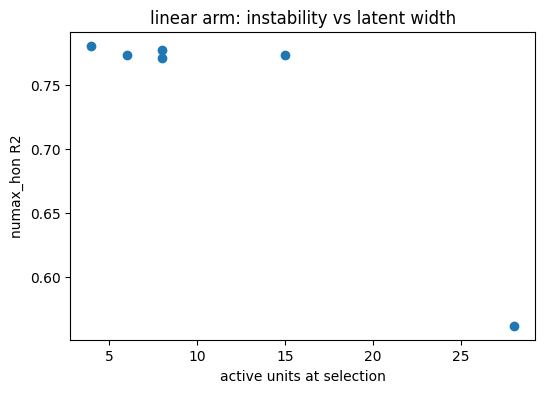

In [17]:
units = shipped[shipped["cell"] == "exp08_linear"][["seed", "val_n_active_units", "epoch", "last_epoch"]]
linear_scores = menu_long[menu_long["cell"] == "exp08_linear"].pivot_table(index="seed", columns="task", values="score")
v1_linear = scores_long[(scores_long["cell"] == "exp08_linear") & (scores_long["pooling"] == "mean_resid")]
v1_linear = v1_linear.pivot_table(index="seed", columns="task", values="score")
v1_linear.columns = v1_linear.columns + "_v1"
joined = units.set_index("seed").join(linear_scores).join(v1_linear)
display(joined.round(3))

rows = []
for column in menu_probes + ["eb_v1", "rotation_v1", "pulsating_v1", "transit_v1"]:
    rho, pval = stats.spearmanr(joined["val_n_active_units"], joined[column])
    rows.append({"target": column, "rho_vs_active_units": rho, "p": pval})
display(pd.DataFrame(rows).round(3))

plt.figure(figsize=(6, 4))
plt.scatter(joined["val_n_active_units"], joined["numax_hon"])
plt.xlabel("active units at selection")
plt.ylabel("numax_hon R2")
plt.title("linear arm: instability vs latent width")
plt.show()

In [18]:
iqr_lo = joined["val_n_active_units"].quantile(0.25)
iqr_hi = joined["val_n_active_units"].quantile(0.75)
kept = joined[(joined["val_n_active_units"] >= iqr_lo) & (joined["val_n_active_units"] <= iqr_hi)].index
print("post-hoc IQR cut keeps seeds:", list(kept), "| active-unit band:", iqr_lo, "to", iqr_hi)
rows = []
for task in ["eb", "rotation"]:
    sub = scores_long[scores_long["seed"].isin(kept)]
    rows.append({"task": task, "post_hoc_cut": True, **paired_delta(sub, "exp08_linear", gru, task, "mean_resid")})
    rows.append({"task": task, "post_hoc_cut": False, **paired_delta(scores_long, "exp08_linear", gru, task, "mean_resid")})
display(pd.DataFrame(rows).round(4))

post-hoc IQR cut keeps seeds: [2, 5] | active-unit band: 6.5 to 13.25


,task,post_hoc_cut,cell_a,cell_b,pooling,n_seeds,mean_a,mean_b,delta,se
0,eb,True,exp08_linear,exp07_hann0p3_fbwd,mean_resid,2,0.5894,0.5843,0.0051,0.0170
1,eb,False,exp08_linear,exp07_hann0p3_fbwd,mean_resid,6,0.5752,0.5905,-0.0153,0.0133
2,rotation,True,exp08_linear,exp07_hann0p3_fbwd,mean_resid,2,0.4268,0.4350,-0.0081,0.0128
3,rotation,False,exp08_linear,exp07_hann0p3_fbwd,mean_resid,6,0.4211,0.4314,-0.0103,0.0091


#### Plain-English read of F

The equivalence is directional, and on one task it is fragile. `linear` minus GRU is mildly negative on
all four v1 tasks and never becomes significantly positive under any leave-one-out subset, so linear
never overtakes the GRU. Two tasks cross the bar downward: pulsating reaches minus 2.49 SE, which is the
published pulsating penalty and not news, and rotation reaches minus 2.29 SE, which is, because it means
"statistically indistinguishable on eb and rotation" holds on eb at every subset but on rotation only at
the full six seeds. Transit changes sign between subsets on a delta of 0.008, noise around zero.
Out of distribution the leave-one-out ranges on `numax_hon` and `rotation_period` are wide and track the
seeds whose latents stayed narrow. The active-unit correlation is suggestive rather than decisive on six
points, and the IQR row is printed only to show what a post-hoc cut would have done, not as evidence.

## G. Does the ladder ordering depend on the pooling?

Every v1 number above is `mean_perp_amp` and every menu number is `mean`. If the ladder ordering moved
with the readout, the contrast between the blocks would be a readout artefact.

In [19]:
rows = []
for pooling in ["mean_resid", "mean", "mean_std"]:
    table = ladder_means[ladder_means["pooling"] == pooling].pivot_table(index="task", columns="cell", values="score")
    table = table[cells_order]
    for task in table.index:
        ranking = table.loc[task].rank(ascending=False)
        rows.append({"pooling": pooling_label[pooling], "task": task,
                     "order": " > ".join(table.loc[task].sort_values(ascending=False).index.str.replace("exp0._", "", regex=True))})
display(pd.DataFrame(rows))

reference = ladder_means[ladder_means["pooling"] == "mean_resid"].pivot_table(index="task", columns="cell", values="score")[cells_order]
for pooling in ["mean", "mean_std"]:
    other = ladder_means[ladder_means["pooling"] == pooling].pivot_table(index="task", columns="cell", values="score")[cells_order]
    rhos = []
    for task in reference.index:
        rho, _ = stats.spearmanr(reference.loc[task], other.loc[task])
        rhos.append({"task": task, "rho_vs_mean_perp_amp": rho})
    print(pooling_label[pooling])
    display(pd.DataFrame(rhos).round(3))

,pooling,task,order
0,mean_perp_amp,eb,hann0p3_fbwd > frozen > linear > frozen_lo > s...
1,mean_perp_amp,pulsating,hann0p3_fbwd > hann0p3_off > smooth_lo > linea...
2,mean_perp_amp,rotation,frozen > hann0p3_fbwd > linear > frozen_lo > s...
3,mean_perp_amp,transit,hann0p3_fbwd > linear > smooth_lo > hann0p3_of...
4,mean,eb,linear > hann0p3_fbwd > frozen > frozen_lo > h...
5,mean,pulsating,hann0p3_off > smooth_lo > hann0p3_fbwd > linea...
6,mean,rotation,hann0p3_fbwd > smooth_lo > frozen > linear > h...
7,mean,transit,linear > hann0p3_fbwd > hann0p3_off > smooth_l...
8,mean_std,eb,hann0p3_fbwd > linear > frozen > frozen_lo > h...
9,mean_std,pulsating,hann0p3_fbwd > frozen > hann0p3_off > linear >...


mean


,task,rho_vs_mean_perp_amp
0,eb,0.771
1,pulsating,0.829
2,rotation,0.429
3,transit,0.886


mean_std


,task,rho_vs_mean_perp_amp
0,eb,0.886
1,pulsating,0.600
2,rotation,0.943
3,transit,0.314


In [20]:
menu_pool = []
for pooling in ["mean", "window_score"]:
    frame = menu[(menu["pooling"] == pooling) & (menu["task"].isin(menu_probes))]
    for cell_name, group in frame.groupby(frame["arm"].str.rsplit("_s", n=1).str[0]):
        for task, sub in group.groupby("task"):
            if sub["shape"].iloc[0] == "regression":
                value = sub["r2"].mean()
            else:
                value = sub["pr_auc"].mean()
            menu_pool.append({"pooling": pooling, "cell": cell_name, "task": task, "score": value})
menu_pool = pd.DataFrame(menu_pool).pivot_table(index=["task", "pooling"], columns="cell", values="score")
display(menu_pool.round(3))

cell                          frozen  frozen_lo  linear  smooth  smooth_half  smooth_lo
task            pooling                                                                
ijspeert        mean           0.440      0.419   0.429   0.313        0.322      0.400
numax_hon       mean           0.739      0.755   0.739   0.287        0.318      0.734
osc_giant       mean           0.810      0.814   0.839   0.740        0.750      0.815
                window_score   0.756      0.713   0.792   0.677        0.681      0.725
rgb_vs_heb      mean           0.801      0.793   0.799   0.716        0.706      0.794
rotation_period mean           0.523      0.559   0.604   0.200        0.269      0.568
solar_like_osc  mean           0.304      0.290   0.297   0.186        0.189      0.290
                window_score   0.261      0.244   0.247   0.178        0.176      0.254

#### Plain-English read of G

The ordering is only partly readout-invariant, and the honest statement is coarser than the writeup's.
What survives every readout is the separation the mechanism claim rests on: the collapsed smooth arms
sit far below, and the pressured arms (linear, wide-frozen, GRU) sit at the top. What moves is the fine
ordering inside that top group, with rank correlations against `mean_perp_amp` running 0.43 to 0.94 and
the GRU numerically first on three of four tasks at `mean_perp_amp` but only one of four at `mean`,
where `linear` takes eb and `off` takes pulsating. Two consequences: the v1 "equivalence" is if anything
stronger at the absolute readout, and G-prior weakens further there, with `smooth_lo` minus `off` on eb
falling to minus 0.0008 plus or minus 0.0068, so the smoothness prior buys literally nothing once
amplitude is left in. The menu ordering does hold under `window_score` pooling.

## H. The mechanism signature

The signature suite claims the private, feature-complementary directions travel with the benefit rather
than with learning. CCA alone cannot support that, since two latents can differ without differing
usefully, so every CCA panel is shown beside the residual probe that measures which side carries content.

In [21]:
resid = sig_resid.groupby(["recipe", "direction"])["resid_var_frac"].mean().unstack()
resid["asymmetry"] = resid["fbwd_perp_off"] / resid["off_perp_fbwd"]
eb_resid = sig_resid[sig_resid["task"] == "eb"].groupby(["recipe", "direction"])["pr_auc"].mean().unstack()
signature = resid.join(eb_resid, rsuffix="_eb_pr_auc")
display(signature.round(4))

for recipe, want in [("exp08_smooth_lo", 0.24), ("exp08_frozen_lo", 1.06), ("exp08_linear", 2.9), ("exp08_frozen", 12.8)]:
    check("signature", recipe + " residual-variance asymmetry", signature.loc[recipe, "asymmetry"], want, tol=0.05, fail_tol=0.5)
display(pd.DataFrame(ledger)[lambda d: d["item"] == "signature"].round(3))

direction,fbwd_perp_off,off_perp_fbwd,asymmetry,fbwd_perp_off_eb_pr_auc,off_perp_fbwd_eb_pr_auc
recipe,,,,,
exp08_frozen,0.0417,0.0033,12.8135,0.2601,0.1706
exp08_frozen_lo,0.0027,0.0026,1.0632,0.2119,0.1848
exp08_linear,0.0115,0.0040,2.8851,0.3042,0.1556
exp08_smooth_lo,0.0024,0.0096,0.2449,0.2130,0.2052


,item,quantity,recomputed,published,abs_diff,status
37,signature,exp08_smooth_lo residual-variance asymmetry,0.245,0.24,0.005,PASS
38,signature,exp08_frozen_lo residual-variance asymmetry,1.063,1.06,0.003,PASS
39,signature,exp08_linear residual-variance asymmetry,2.885,2.90,0.015,PASS
40,signature,exp08_frozen residual-variance asymmetry,12.813,12.80,0.013,PASS


,cross_arm,same_cell_fbwd,same_cell_off,asymmetry,fbwd_perp_off_eb_pr_auc,off_perp_fbwd_eb_pr_auc
label,,,,,,
exp08_frozen,0.3723,0.8127,0.6268,12.8135,0.2601,0.1706
exp08_frozen_lo,0.6835,0.7952,0.6268,1.0632,0.2119,0.1848
exp08_linear,0.3848,0.6761,0.6268,2.8851,0.3042,0.1556
exp08_smooth_lo,0.4221,0.7139,0.6268,0.2449,0.2130,0.2052


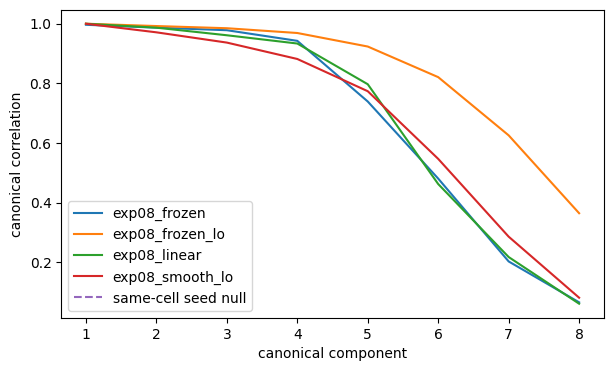

In [22]:
tail = sig_cca[sig_cca["component"] > 4].groupby(["pair", "label"])["cancorr"].mean().unstack(0)
paired_view = tail.join(signature[["asymmetry", "fbwd_perp_off_eb_pr_auc", "off_perp_fbwd_eb_pr_auc"]])
display(paired_view.round(4))

plt.figure(figsize=(7, 4))
for label, group in sig_cca[sig_cca["pair"] == "cross_arm"].groupby("label"):
    curve = group.groupby("component")["cancorr"].mean()
    plt.plot(curve.index, curve.values, label=label)
null_curve = sig_cca[sig_cca["pair"] == "seed_null"].groupby("component")["cancorr"].mean()
plt.plot(null_curve.index, null_curve.values, label="same-cell seed null", linestyle="--")
plt.xlabel("canonical component")
plt.ylabel("canonical correlation")
plt.legend()
plt.show()

#### Plain-English read of H

All four published asymmetry ratios reproduce, and they order exactly as the probe scores do: wide-frozen
at 12.8, linear at 2.9, collapsed-frozen at 1.06 and smoothness inverted at 0.24. Placed beside the
residual probes the pair tells the story CCA alone cannot: `smooth_lo` does separate from the seed null,
yet its two residual directions probe symmetrically (0.213 against 0.205), meaning its private directions
are different without being differently useful, while `linear` and wide-frozen carry 0.304 against 0.156
and 0.260 against 0.171. The signature follows the benefit, not the learning.

## I. What exp08 cannot answer

Three limitations are stated rather than measured, because closing them needs training runs this
notebook is not allowed to launch.

In [23]:
dose_points = pd.DataFrame([
    {"cell": "exp08_smooth_lo", "lambda": 15, "achieved_dose": 0.055, "active_units": 4,
     "note": "max pressure without collapse"},
    {"cell": "exp08_smooth_half", "lambda": 135, "achieved_dose": None, "active_units": 1,
     "note": "saturation replicate, NOT a dose-0.5 cell"},
    {"cell": "exp08_smooth", "lambda": 270, "achieved_dose": 0.007, "active_units": 1,
     "note": "saturated, latent collapsed"},
    {"cell": "exp08_frozen_lo", "lambda": 9, "achieved_dose": 0.401, "active_units": 5,
     "note": "collapsed phase"},
    {"cell": "exp08_frozen", "lambda": 22, "achieved_dose": 2.37, "active_units": 101,
     "note": "wide phase, violates the dose gate"},
])
display(dose_points)
print("smooth lambda points run:", [15, 135, 270], "| nothing between 15 and 135 was ever run")
print("frozen lambda points run:", [9, 22], "| no lambda stably delivers dose 1.0")

,cell,lambda,achieved_dose,active_units,note
0,exp08_smooth_lo,15,0.055,4,max pressure without collapse
1,exp08_smooth_half,135,NaN,1,"saturation replicate, NOT a dose-0.5 cell"
2,exp08_smooth,270,0.007,1,"saturated, latent collapsed"
3,exp08_frozen_lo,9,0.401,5,collapsed phase
4,exp08_frozen,22,2.370,101,"wide phase, violates the dose gate"


smooth lambda points run: [15, 135, 270] | nothing between 15 and 135 was ever run
frozen lambda points run: [9, 22] | no lambda stably delivers dose 1.0


#### The stated limitations

**Smooth lambda gap (#3).** "Max pressure without collapse" rests on two lambda points, 15 and 135, with
nothing in between. Whether some intermediate lambda holds more than four units is untested and would
cost six runs; it is flagged, not run. Combined with the gates' consistently positive but non-significant
deltas, the honest phrasing is that smoothness delivers a small effect this design cannot resolve, not
that it delivers nothing.

**Frozen bistability (#4).** The collapsed-versus-wide phase story rests on two lambda points, 9 and 22,
bracketing a dose target no lambda reached stably. Each frozen seed also froze a different random GRU,
so its seed variance mixes the init draw with the data order; this was intended, and it means the frozen
arm's spread is not comparable to a learned arm's.

**smooth_half (#8).** Both smooth cells sit at the saturation floor, so `smooth_half` is a saturation
replicate and never a dose-0.5 cell. Every table above labels it that way, and any figure reusing these
numbers must too, or a reader will infer a dose axis that does not exist.

**Rotation shadow (#9)** was measurable and is answered in section C: eb carries both gates alone.

## Summary

In [24]:
ledger_frame = pd.DataFrame(ledger)
display(ledger_frame.round(4))
display(ledger_frame["status"].value_counts())

,item,quantity,recomputed,published,abs_diff,status
0,#6 selection,smooth active units (all seeds),1.0000,1.000,0.0000,PASS
1,#6 selection,smooth_half active units (all seeds),1.0000,1.000,0.0000,PASS
2,#6 selection,smooth_lo active units,4.0000,4.000,0.0000,PASS
3,#6 selection,frozen_lo active units (max),5.0000,5.000,0.0000,PASS
4,#6 selection,frozen wide active units (min),69.0000,69.000,0.0000,PASS
5,#6 selection,frozen wide active units (max),116.0000,114.000,2.0000,DRIFT
6,#2 linear,linear active units (max),28.0000,29.000,1.0000,DRIFT
7,ladder,eb / exp07_hann0p3_off,0.5102,0.510,0.0002,PASS
8,ladder,eb / exp08_smooth_lo,0.5290,0.529,0.0000,PASS
9,ladder,eb / exp08_linear,0.5752,0.575,0.0002,PASS


status
PASS     39
DRIFT     2
Name: count, dtype: int64

In [25]:
summary = pd.DataFrame([
    {"item": "#1 menu twist", "tag": "NEW",
     "finding": "paired per-seed redo: GRU top on 5/6 probes, > 2 SE over the best fair rung on 2/6 (numax_hon, solar_like_osc), never significantly behind; rule-B verdict downgrades 'leads the entire ladder' to 'best-rounded'"},
    {"item": "#1 v1 contrast", "tag": "CONFIRMED",
     "finding": "GRU beats the best fair rung by > 2 SE on 0/4 v1 tasks at both mean_perp_amp and mean (numerically top 3/4 and 1/4), so the in-distribution equivalence is real at both readouts"},
    {"item": "#2 linear instability", "tag": "NEW",
     "finding": "linear never overtakes the GRU under any leave-one-seed-out subset; the equivalence holds on eb at every subset but on rotation only at the full six seeds (one subset reaches -2.29 SE), and out-of-distribution spread tracks the seeds whose latent stayed narrow"},
    {"item": "#5 stop epoch", "tag": "NEW",
     "finding": "no consistent within-cell relation between stop epoch and probe score, so cross-arm seed pairing is not comparing learning-rate exposure"},
    {"item": "#6 selection sanity", "tag": "CONFIRMED",
     "finding": "all 38 shipped checkpoints past warmup, present in their own curve, best_select equal to the curve monitor; smooth arms show exactly 1 active unit; frozen spans 69-116 and linear 4-28 against a published 69-114 and 4-29"},
    {"item": "#7 cache provenance", "tag": "CONFIRMED",
     "finding": "no content-hash collision across 132 caches, so no arm fell back to another cell's checkpoint; cache widths reproduce the arms' ordering; the four off-arm scaling copies are identical and dedup shifts nothing"},
    {"item": "#8 smooth_half", "tag": "CAVEAT",
     "finding": "labelled a saturation replicate everywhere; both smooth cells sit at the saturation floor and there is no dose axis between them"},
    {"item": "#9 rotation shadow", "tag": "NEW",
     "finding": "both gates keep their verdicts on eb alone and at every readout; at mean the smoothness prior buys -0.0008 +/- 0.0068 on eb, so G-prior FAILs harder there than at mean_perp_amp"},
    {"item": "#10 CCA display", "tag": "CONFIRMED",
     "finding": "asymmetry ratios reproduce (0.24 / 1.06 / 2.9 / 12.8); smooth_lo separates from the seed null yet probes symmetrically, which only the residual pair reveals"},
    {"item": "B4 pooling", "tag": "NEW",
     "finding": "only the coarse ordering is readout-invariant (collapsed smooth far below, pressured arms on top); rank correlations against mean_perp_amp run 0.43 to 0.94 and the fine ordering inside the top group moves, so every ladder table must quote its readout"},
    {"item": "L2 estimator", "tag": "CONFIRMED",
     "finding": "independent re-fit reproduces mean and mean_std bit-exactly on the two load-bearing cells; mean_perp_amp scatters 0.0015 per run, unbiased, below 0.0002 at the six-seed cell mean"},
    {"item": "#3 smooth lambda gap", "tag": "CAVEAT", "finding": "two lambda points only, nothing between 15 and 135; six runs would close it, not run"},
    {"item": "#4 frozen bistability", "tag": "CAVEAT", "finding": "two lambda points bracketing an unreachable dose; each seed froze a different random GRU"},
    {"item": "curve provenance", "tag": "NEW",
     "finding": "exp07_hann0p3_fbwd seed 3's curve dump starts at epoch 37 (resumed run); epoch-range statistics on that one reference run are unusable"},
])
display(summary)

,item,tag,finding
0,#1 menu twist,NEW,"paired per-seed redo: GRU top on 5/6 probes, >..."
1,#1 v1 contrast,CONFIRMED,GRU beats the best fair rung by > 2 SE on 0/4 ...
2,#2 linear instability,NEW,linear never overtakes the GRU under any leave...
3,#5 stop epoch,NEW,no consistent within-cell relation between sto...
4,#6 selection sanity,CONFIRMED,"all 38 shipped checkpoints past warmup, presen..."
5,#7 cache provenance,CONFIRMED,"no content-hash collision across 132 caches, s..."
6,#8 smooth_half,CAVEAT,labelled a saturation replicate everywhere; bo...
7,#9 rotation shadow,NEW,both gates keep their verdicts on eb alone and...
8,#10 CCA display,CONFIRMED,asymmetry ratios reproduce (0.24 / 1.06 / 2.9 ...
9,B4 pooling,NEW,only the coarse ordering is readout-invariant ...


### Verdict lines for the claims-matrix refresh

**#1.** The pre-registered rule returns *best-rounded*, not *leads*. The publishable sentence is: on the
downstream menu the GRU is numerically ahead of every rung on five of six probes and never significantly
behind, and its lead clears two SE over the best competing rung on `numax_hon` and `solar_like_osc`. The
README's "on every transfer probe the GRU leads the entire ladder" overstates a five-of-six numerical
ordering; the contrast against v1, where the GRU clears no rung on any task, is the part that holds
unambiguously.

**#2.** "A learned linear map matches the GRU on eb and rotation" survives with one qualification: linear
never overtakes the GRU under any leave-one-seed-out subset, and the equivalence holds on eb at every
subset, but on rotation a single dropped seed carries the delta to minus 2.29 SE, so the rotation half
of the claim rests on the full six seeds. Linear's instability is otherwise an out-of-distribution
phenomenon, where its seed spread runs an order of magnitude above the GRU's.

**B4 / readout.** The ladder ordering is only coarsely readout-invariant, so every table and figure
built on these numbers must state which readout it uses; "the ladder ordering" without a readout is not
a well-defined claim.

**Untrained references.** Nothing above prints a gap against `untrained_w256`, which is a single fixed
init; the six-init spread exists only for the Gate-0 menu arms.

In [26]:
failures = ledger_frame[ledger_frame["status"] == "FAIL"]
display(failures)
assert len(failures) == 0, "a published number failed to reproduce: see the ledger above"
print("audit complete:", len(ledger_frame), "checks,", (ledger_frame["status"] == "PASS").sum(), "pass,",
      (ledger_frame["status"] == "DRIFT").sum(), "drift")

,item,quantity,recomputed,published,abs_diff,status


audit complete: 41 checks, 39 pass, 2 drift
